In [32]:
from Bio import PDB
import math
import os
import requests
import numpy as np

In [33]:
def load_codes(filepath):
    with open(filepath, "r", encoding="utf-8-sig") as f:
        codes = f.read().split()
    return codes

codes = load_codes("protein_codes.txt")
print(codes[:10])

['101M', '102L', '102M', '103L', '103M', '104L', '104M', '105M', '106M', '107L']


In [34]:
from Bio import PDB
import math

def get_ramachandran_coordinates(file_path):
    """
    Extracts only the phi (x) and psi (y) angles from a PDB file.
    Returns a dictionary with lists of x and y values.
    """
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('input_structure', file_path)
    
    ramachandran_data = {"x": [], "y": []}

    for model in structure:
        for chain in model:
            polypeptides = PDB.PPBuilder().build_peptides(chain)
            for poly in polypeptides:
                phi_psi = poly.get_phi_psi_list()
                
                for i, (phi, psi) in enumerate(phi_psi):
                    # Only append if both angles are present (not None)
                    if phi is not None and psi is not None:
                        # Convert radians to degrees
                        ramachandran_data["x"].append(math.degrees(phi))
                        ramachandran_data["y"].append(math.degrees(psi))
    ramachandran_data["x"] = np.array(ramachandran_data["x"])
    ramachandran_data["y"] = np.array(ramachandran_data["y"])
    coords = np.column_stack((ramachandran_data["x"], ramachandran_data["y"])) 
    return coords

In [35]:
def download_pdb_file(pdb_id, download_dir="."):
    """
    Downloads the .pdb file directly from RCSB using the PDB ID.
    """
    pdb_id = pdb_id.upper()
    pdb_file = f"{pdb_id}.pdb"
    file_path = os.path.join(download_dir, pdb_file)
    
    # Check if file already exists to save time/bandwidth
    if os.path.exists(file_path):
        print(f"File {pdb_file} already exists. Using local copy.")
        return file_path

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    
    try:
        print(f"Downloading {pdb_id}...")
        response = requests.get(url)
        response.raise_for_status() # Raises error for 404 (ID not found)
        
        with open(file_path, 'wb') as f:
            f.write(response.content)
        print(f"Download complete: {file_path}")
        return file_path
    except requests.exceptions.HTTPError:
        print(f"Error: PDB ID '{pdb_id}' not found on RCSB.")
        return None
    except Exception as e:
        print(f"Error downloading PDB: {e}")
        return None

def extract_backbone_coords(file_path):
    """
    Extracts the backbone (N, CA, C) coordinates from the PDB file.
    Returns a numpy array of shape (3*n_residues, 3)
    """
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('backbone_extraction', file_path)
    
    backbone_coords = []
    for model in structure:
        for chain in model:
            for res in chain:
                for atom_name in ("N", "CA", "C"):
                    if atom_name in res:
                        backbone_coords.append(res[atom_name].get_coord())
    return np.vstack(backbone_coords)

# --- Main Pipeline ---

def process_pdb_pipeline(pdb_id):
    """
    Takes a PDB ID, downloads the file, calculates angles, extracts sequence and 3D coords.
    """
    # 1. Download PDB
    file_path = download_pdb_file(pdb_id)
    if not file_path:
        return None

    # 2. Get Ramachandran Coordinates
    coords = get_ramachandran_coordinates(file_path)

    # 3. Extract Sequence
    sequence = extract_sequence(file_path)

    # 4. Extract Backbone Coordinates
    backbone_coords = extract_backbone_coords(file_path)

    # 5. Package Results
    result = {
        "pdb_id": pdb_id,
        "sequence": sequence,
        "ramachandran": coords,
        "backbone_coords": backbone_coords
    }
    
    return result


In [38]:
# -- Insert codes list into main Pipeline --
backbone_coords_dict = {}

# Process first 1019 proteins (the dataset model(1019).pth was trained on)
num_proteins = min(1019, len(codes))
print(f"Processing {num_proteins} proteins for training...")

for i, pdb_id in enumerate(codes[:num_proteins]):
    print(f"[{i+1}/{num_proteins}] Processing {pdb_id}...", end=" ")
    
    # Download PDB
    pdb_path = download_pdb_file(pdb_id)
    if not pdb_path:
        print("(failed to download)")
        continue
    
    # Extract backbone coordinates (ground truth for training)
    try:
        backbone_coords = extract_backbone_coords(pdb_path)
        backbone_coords_dict[pdb_id] = backbone_coords
        print(f"(extracted {backbone_coords.shape[0]} atoms, deleting file)")
    except Exception as e:
        print(f"(extraction failed: {e})")
    
    # Delete the PDB file after extraction
    try:
        os.remove(pdb_path)
    except Exception as e:
        print(f"Warning: Could not delete {pdb_path}: {e}")
    
    if (i + 1) % 50 == 0:
        print(f"  → Processed {i+1} proteins so far...")

print(f"\nTotal proteins processed: {len(backbone_coords_dict)}")

# Save backbone coordinates
import pickle
with open('backbone_coords.pkl', 'wb') as f:
    pickle.dump(backbone_coords_dict, f)
print("Saved all backbone coordinates to backbone_coords.pkl")


Processing 1019 proteins for training...
[1/1019] Processing 101M... Downloading 101M...
Download complete: ./101M.pdb
(extracted 464 atoms, deleting file)
[2/1019] Processing 102L... Downloading 102L...
Download complete: ./102L.pdb
(extracted 489 atoms, deleting file)
[3/1019] Processing 102M... Downloading 102M...
Download complete: ./102M.pdb
(extracted 462 atoms, deleting file)
[4/1019] Processing 103L... Downloading 103L...
Download complete: ./103L.pdb
(extracted 477 atoms, deleting file)
[5/1019] Processing 103M... Downloading 103M...
Download complete: ./103M.pdb
(extracted 464 atoms, deleting file)
[6/1019] Processing 104L... Downloading 104L...
Download complete: ./104L.pdb
(extracted 984 atoms, deleting file)
[7/1019] Processing 104M... Downloading 104M...
Download complete: ./104M.pdb
(extracted 461 atoms, deleting file)
[8/1019] Processing 105M... Downloading 105M...
Download complete: ./105M.pdb
(extracted 461 atoms, deleting file)
[9/1019] Processing 106M... Downloading

## Plot from protein_features.pkl dictiornary

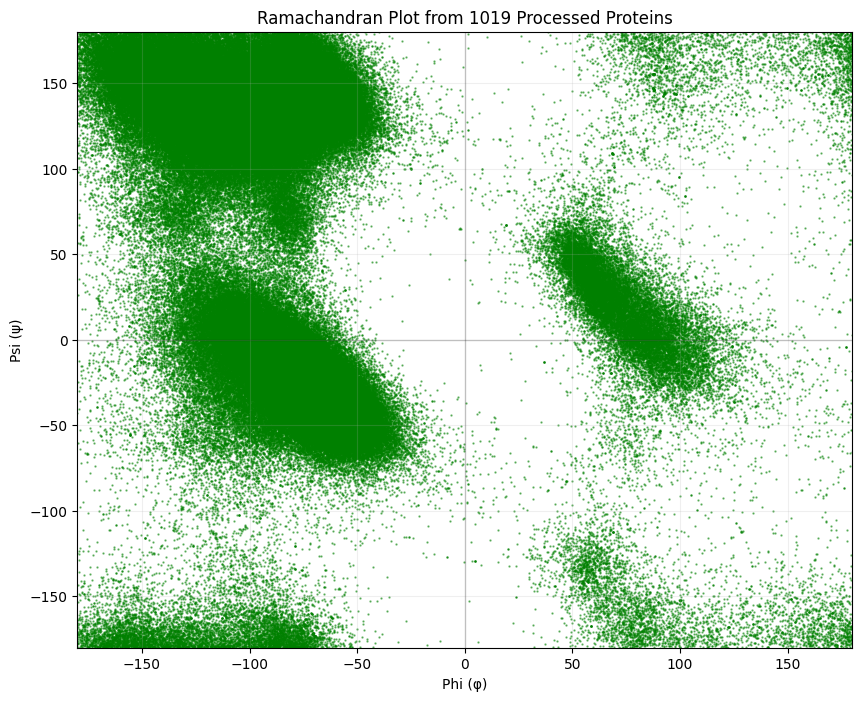

In [39]:
%matplotlib inline
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load the extracted features
with open('protein_features.pkl', 'rb') as f:
    protein_dict = pickle.load(f)

# Aggregate all coordinate points
all_coords = [data['coords'] for data in protein_dict.values()]
coords = np.vstack(all_coords)

# Create the plot
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=0.5, c='green')
plt.title(f'Ramachandran Plot from {len(protein_dict)} Processed Proteins')
plt.xlabel('Phi (φ)')
plt.ylabel('Psi (ψ)')
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.axhline(0, color='black', lw=1, alpha=0.2)
plt.axvline(0, color='black', lw=1, alpha=0.2)
plt.grid(True, alpha=0.2)
plt.show()

In [40]:
coords.shape

(488545, 2)

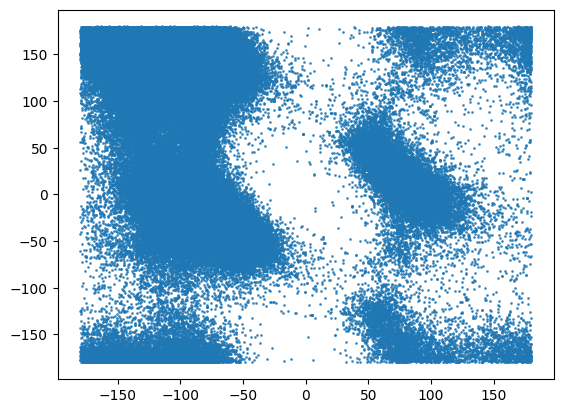

In [41]:
plt.scatter(x=coords[:,0], y=coords[:,1], alpha=0.75, s=1)

## Flow Matching

In [42]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [43]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [44]:
flow = Flow()
flow.load_state_dict(torch.load("model(1019).pth", map_location=torch.device('cpu')))
flow.eval()

Flow(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

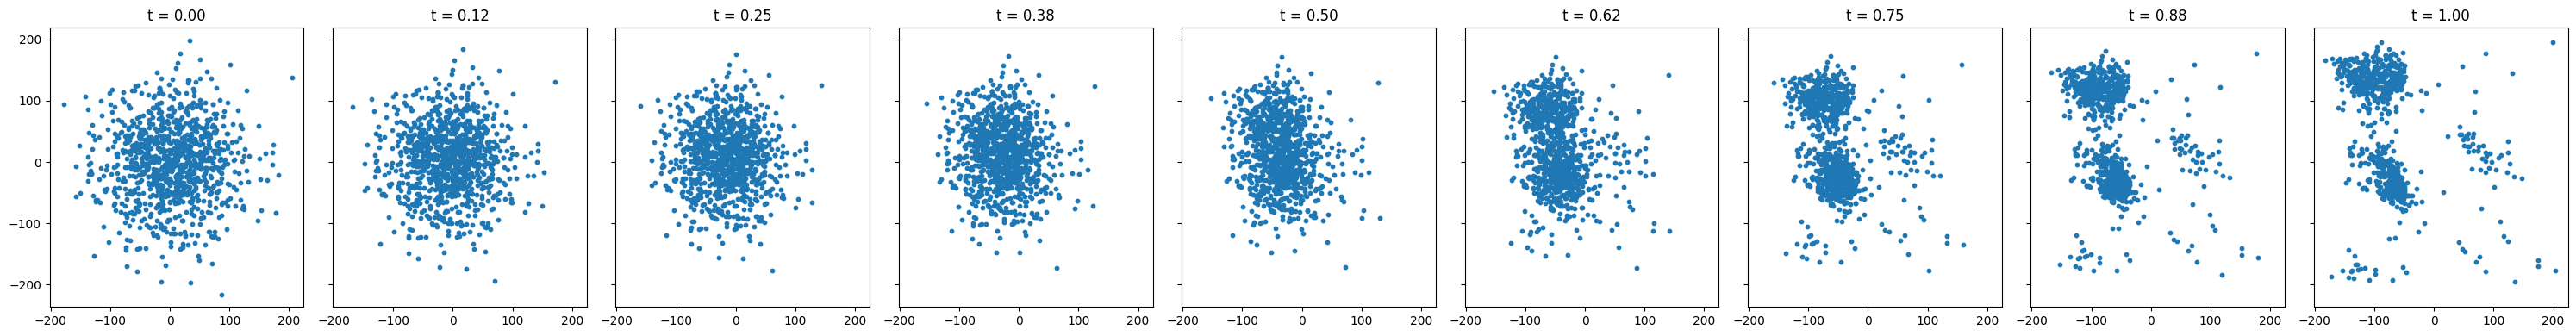

In [24]:
x = torch.randn(1000, 2) * 60
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
#axes[0].set_xlim(-3.0, 3.0)
#axes[0].set_ylim(-3.0, 3.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle
import torch

# Assumed existing helpers
# def download_pdb_file(pdb_id): ...
# def get_ramachandran_coordinates(pdb_path): ...

BACKBONE_FILE = "backbone_coords.pkl"
TORSION_CACHE_FILE = "true_torsions.pkl"

with open(BACKBONE_FILE, "rb") as f:
    backbone_dict = pickle.load(f)

true_torsion_dict = {}
failed_ids = []

print(f"Extracting true torsions for {len(backbone_dict)} proteins...")

for i, pdb_id in enumerate(backbone_dict.keys(), 1):
    try:
        pdb_path = download_pdb_file(pdb_id)
        tors = get_ramachandran_coordinates(pdb_path)  # expected shape (n_res, 2)

        if tors is None or len(tors) == 0:
            failed_ids.append(pdb_id)
            print(f"[{i}] Skipping {pdb_id}: no torsions found")
            continue

        true_torsion_dict[pdb_id] = torch.tensor(tors, dtype=torch.float32)

        print(f"[{i}] Saved torsions for {pdb_id} with shape {true_torsion_dict[pdb_id].shape}")

    except Exception as e:
        failed_ids.append(pdb_id)
        print(f"[{i}] Failed {pdb_id}: {e}")

    finally:
        try:
            if "pdb_path" in locals() and os.path.exists(pdb_path):
                os.remove(pdb_path)
        except:
            pass

with open(TORSION_CACHE_FILE, "wb") as f:
    pickle.dump(
        {
            "torsions": true_torsion_dict,
            "failed_ids": failed_ids,
        },
        f
    )

print(f"\nSaved torsion cache to: {TORSION_CACHE_FILE}")
print(f"Successful: {len(true_torsion_dict)}")
print(f"Failed: {len(failed_ids)}")

Extracting true torsions for 1019 proteins...
Download complete: ./101M.pdb
[1] Saved torsions for 101M with shape torch.Size([152, 2])
Download complete: ./102L.pdb
[2] Saved torsions for 102L with shape torch.Size([161, 2])
Download complete: ./102M.pdb
[3] Saved torsions for 102M with shape torch.Size([152, 2])
Download complete: ./103L.pdb
[4] Saved torsions for 103L with shape torch.Size([155, 2])
Download complete: ./103M.pdb
[5] Saved torsions for 103M with shape torch.Size([152, 2])
Download complete: ./104L.pdb
[6] Saved torsions for 104L with shape torch.Size([324, 2])
Download complete: ./104M.pdb
[7] Saved torsions for 104M with shape torch.Size([151, 2])
Download complete: ./105M.pdb
[8] Saved torsions for 105M with shape torch.Size([151, 2])
Download complete: ./106M.pdb
[9] Saved torsions for 106M with shape torch.Size([152, 2])
Download complete: ./107L.pdb
[10] Saved torsions for 107L with shape torch.Size([160, 2])
Download complete: ./107M.pdb
[11] Saved torsions for

In [85]:
import math
import random
import pickle
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv


# ============================================================
# Config
# ============================================================
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_SUBSET = True
TRAIN_SUBSET_SIZE = 100
VAL_SUBSET_SIZE = 30
BATCH_SIZE = 1
EPOCHS = 10
LR = 1e-3
HIDDEN_DIM = 128
VAL_RATIO = 0.15
MAX_DELTA_DEG = 30.0

BACKBONE_FILE = "backbone_coords.pkl"
TORSION_CACHE_FILE = "true_torsions.pkl"

print("Using device:", DEVICE)

# Helpful while debugging backward errors
# You can comment this out later for speed
#torch.autograd.set_detect_anomaly(True)


# ============================================================
# Geometry constants
# ============================================================
def deg2rad(x):
    return x * math.pi / 180.0


BOND_LENGTHS = {
    "N_CA": 1.458,
    "CA_C": 1.525,
    "C_N": 1.329,
}

BOND_ANGLES = {
    "C_N_CA": deg2rad(121.7),
    "N_CA_C": deg2rad(110.4),
    "CA_C_N": deg2rad(116.2),
}

OMEGA_TRANS = math.pi


# ============================================================
# Graph builder
# ============================================================
def build_chain_edges(n_res: int) -> torch.Tensor:
    edge_pairs = []
    for i in range(n_res - 1):
        edge_pairs.append([i, i + 1])
        edge_pairs.append([i + 1, i])
    if len(edge_pairs) == 0:
        edge_pairs = [[0, 0]]
    return torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()


# ============================================================
# NeRF extension
# ============================================================
def nerf_extend(
    a: torch.Tensor,
    b: torch.Tensor,
    c: torch.Tensor,
    bond_length: torch.Tensor,
    bond_angle: torch.Tensor,
    torsion: torch.Tensor,
) -> torch.Tensor:
    """
    a, b, c: (..., 3)
    returns d: (..., 3)
    """
    if bond_length.ndim == 0:
        bond_length = bond_length.view(1)
    if bond_angle.ndim == 0:
        bond_angle = bond_angle.view(1)
    if torsion.ndim == 0:
        torsion = torsion.view(1)

    bc = c - b
    bc_unit = bc / (torch.norm(bc, dim=-1, keepdim=True) + 1e-8)

    ba = b - a
    n = torch.cross(ba, bc, dim=-1)
    n_unit = n / (torch.norm(n, dim=-1, keepdim=True) + 1e-8)

    m = torch.cross(n_unit, bc_unit, dim=-1)

    if bond_length.ndim == 1:
        bond_length = bond_length.view(-1, 1)
    if bond_angle.ndim == 1:
        bond_angle = bond_angle.view(-1, 1)
    if torsion.ndim == 1:
        torsion = torsion.view(-1, 1)

    d_local = (
        -torch.cos(bond_angle) * bc_unit
        + torch.sin(bond_angle)
        * (torch.cos(torsion) * m + torch.sin(torsion) * n_unit)
    )

    d = c + bond_length * d_local
    return d


# ============================================================
# Backbone builder from torsions
# ============================================================
def build_backbone_from_torsions(
    phi: torch.Tensor,
    psi: torch.Tensor,
    omega: torch.Tensor = None,
    device=None,
) -> torch.Tensor:
    if device is None:
        device = phi.device

    n_res = phi.shape[0]
    assert n_res >= 1

    if omega is None:
        omega = torch.full(
            (max(n_res - 1, 1),),
            OMEGA_TRANS,
            dtype=phi.dtype,
            device=device,
        )

    N0 = torch.tensor([0.0, 0.0, 0.0], dtype=phi.dtype, device=device)
    CA0 = torch.tensor([BOND_LENGTHS["N_CA"], 0.0, 0.0], dtype=phi.dtype, device=device)

    theta = BOND_ANGLES["N_CA_C"]
    C0 = torch.tensor(
        [
            BOND_LENGTHS["N_CA"] - BOND_LENGTHS["CA_C"] * math.cos(math.pi - theta),
            BOND_LENGTHS["CA_C"] * math.sin(math.pi - theta),
            0.0,
        ],
        dtype=phi.dtype,
        device=device,
    )

    coords = [N0, CA0, C0]

    if n_res == 1:
        return torch.stack(coords, dim=0)

    for i in range(1, n_res):
        N_prev = coords[-3]
        CA_prev = coords[-2]
        C_prev = coords[-1]

        omega_i = omega[i - 1] if omega.numel() > 1 else omega[0]

        N_i = nerf_extend(
            N_prev.unsqueeze(0),
            CA_prev.unsqueeze(0),
            C_prev.unsqueeze(0),
            bond_length=torch.tensor([BOND_LENGTHS["C_N"]], dtype=phi.dtype, device=device),
            bond_angle=torch.tensor([BOND_ANGLES["CA_C_N"]], dtype=phi.dtype, device=device),
            torsion=omega_i.unsqueeze(0),
        ).squeeze(0)

        CA_i = nerf_extend(
            CA_prev.unsqueeze(0),
            C_prev.unsqueeze(0),
            N_i.unsqueeze(0),
            bond_length=torch.tensor([BOND_LENGTHS["N_CA"]], dtype=phi.dtype, device=device),
            bond_angle=torch.tensor([BOND_ANGLES["C_N_CA"]], dtype=phi.dtype, device=device),
            torsion=phi[i].unsqueeze(0),
        ).squeeze(0)

        C_i = nerf_extend(
            C_prev.unsqueeze(0),
            N_i.unsqueeze(0),
            CA_i.unsqueeze(0),
            bond_length=torch.tensor([BOND_LENGTHS["CA_C"]], dtype=phi.dtype, device=device),
            bond_angle=torch.tensor([BOND_ANGLES["N_CA_C"]], dtype=phi.dtype, device=device),
            torsion=psi[i].unsqueeze(0),
        ).squeeze(0)

        coords.extend([N_i, CA_i, C_i])

    return torch.stack(coords, dim=0)


# ============================================================
# Safe Kabsch alignment
# ============================================================
def kabsch_align(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    pred, target: (N, 3)
    Returns aligned pred.
    """
    pred_center = pred.mean(dim=0, keepdim=True)
    target_center = target.mean(dim=0, keepdim=True)

    P = pred - pred_center
    Q = target - target_center

    H = P.t() @ Q
    U, S, Vh = torch.linalg.svd(H)

    # No in-place edits on SVD outputs
    det_val = torch.det(Vh.t() @ U.t())
    sign_val = torch.where(
        det_val < 0,
        torch.tensor(-1.0, device=pred.device, dtype=pred.dtype),
        torch.tensor(1.0, device=pred.device, dtype=pred.dtype),
    )

    D = torch.diag(
        torch.stack(
            [
                torch.tensor(1.0, device=pred.device, dtype=pred.dtype),
                torch.tensor(1.0, device=pred.device, dtype=pred.dtype),
                sign_val,
            ]
        )
    )

    R = Vh.t() @ D @ U.t()
    P_aligned = P @ R
    return P_aligned + target_center


def rmsd(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(torch.mean(torch.sum((pred - target) ** 2, dim=-1)))


def aligned_rmsd(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred_aligned = kabsch_align(pred, target)
    return rmsd(pred_aligned, target)


# ============================================================
# Angle features
# ============================================================
def angle_to_features(phi_rad: torch.Tensor, psi_rad: torch.Tensor) -> torch.Tensor:
    return torch.stack(
        [
            torch.sin(phi_rad),
            torch.cos(phi_rad),
            torch.sin(psi_rad),
            torch.cos(psi_rad),
        ],
        dim=-1,
    )


# ============================================================
# Load dataset from cached torsions
# ============================================================
def load_dataset_from_cache(
    backbone_pkl=BACKBONE_FILE,
    torsion_cache_pkl=TORSION_CACHE_FILE,
) -> List[Data]:
    with open(backbone_pkl, "rb") as f:
        backbone_dict = pickle.load(f)

    with open(torsion_cache_pkl, "rb") as f:
        torsion_cache = pickle.load(f)

    true_torsion_dict = torsion_cache["torsions"]

    data_list = []
    skipped = []

    for pdb_id, coords in backbone_dict.items():
        if pdb_id not in true_torsion_dict:
            skipped.append(pdb_id)
            continue

        tors_deg = true_torsion_dict[pdb_id]

        if not isinstance(tors_deg, torch.Tensor):
            tors_deg = torch.tensor(tors_deg, dtype=torch.float32)
        else:
            tors_deg = tors_deg.clone().detach().float()

        if tors_deg.ndim != 2 or tors_deg.shape[1] != 2:
            skipped.append(pdb_id)
            continue

        n_res = tors_deg.shape[0]

        coords = torch.tensor(coords, dtype=torch.float32)
        if coords.ndim != 2 or coords.shape[1] != 3:
            skipped.append(pdb_id)
            continue

        needed_atoms = n_res * 3
        if coords.shape[0] < needed_atoms:
            skipped.append(pdb_id)
            continue

        coords = coords[:needed_atoms]

        # remove global translation
        coords = coords - coords.mean(dim=0, keepdim=True)

        phi_rad = torch.deg2rad(tors_deg[:, 0])
        psi_rad = torch.deg2rad(tors_deg[:, 1])

        x = angle_to_features(phi_rad, psi_rad)
        y_tors = torch.stack([phi_rad, psi_rad], dim=-1)
        edge_index = build_chain_edges(n_res)

        d = Data(x=x, edge_index=edge_index)
        d.y_tors = y_tors
        d.y_coords = coords
        d.pdb_id = pdb_id
        d.n_res = n_res

        data_list.append(d)

    print(f"Loaded dataset with {len(data_list)} proteins")
    print(f"Skipped {len(skipped)} proteins")
    return data_list


# ============================================================
# GNN model
# ============================================================
class TorsionRefineGNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        delta = x * deg2rad(MAX_DELTA_DEG)
        return delta


# ============================================================
# Losses
# ============================================================
def wrapped_angle_diff(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.atan2(torch.sin(a - b), torch.cos(a - b))


def torsion_loss(pred_tors: torch.Tensor, true_tors: torch.Tensor) -> torch.Tensor:
    diff = wrapped_angle_diff(pred_tors, true_tors)
    return torch.mean(diff ** 2)


def backbone_coord_loss(pred_coords: torch.Tensor, true_coords: torch.Tensor) -> torch.Tensor:
    """
    Kabsch-aligned coordinate MSE
    """
    pred_aligned = kabsch_align(pred_coords, true_coords)
    return torch.mean((pred_aligned - true_coords) ** 2)


# ============================================================
# Forward reconstruction
# ============================================================
def forward_reconstruct(model: nn.Module, data: Data):
    x = data.x.to(DEVICE)
    edge_index = data.edge_index.to(DEVICE)
    true_tors = data.y_tors.to(DEVICE)
    true_coords = data.y_coords.to(DEVICE)

    delta = model(x, edge_index)
    pred_tors = true_tors + delta

    phi = pred_tors[:, 0]
    psi = pred_tors[:, 1]

    pred_coords = build_backbone_from_torsions(phi, psi, device=DEVICE)

    return pred_tors, pred_coords, true_tors, true_coords


# ============================================================
# Train and eval
# ============================================================
def train_one_epoch(model, loader, optimizer, lambda_tors=1.0, lambda_coord=10.0):
    model.train()
    total_loss = 0.0

    for i, data in enumerate(loader):
        if (i + 1) % 20 == 0 or i == 0:
            print(f"Processing batch {i+1}/{len(loader)} ...")

        optimizer.zero_grad()
        pred_tors, pred_coords, true_tors, true_coords = forward_reconstruct(model, data)

        lt = torsion_loss(pred_tors, true_tors)
        lc = backbone_coord_loss(pred_coords, true_coords)
        loss = lambda_tors * lt + lambda_coord * lc

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (i + 1) % 20 == 0 or i == 0:
            print(f"  done batch {i+1}, loss={loss.item():.4f}")

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(model, loader, lambda_tors=1.0, lambda_coord=10.0):
    model.eval()
    total_loss = 0.0
    total_tors = 0.0
    total_coord = 0.0
    total_rmsd = 0.0

    for data in loader:
        pred_tors, pred_coords, true_tors, true_coords = forward_reconstruct(model, data)

        lt = torsion_loss(pred_tors, true_tors)
        lc = backbone_coord_loss(pred_coords, true_coords)
        loss = lambda_tors * lt + lambda_coord * lc

        total_loss += loss.item()
        total_tors += lt.item()
        total_coord += lc.item()
        total_rmsd += aligned_rmsd(pred_coords, true_coords).item()

    n = max(len(loader), 1)
    return {
        "loss": total_loss / n,
        "torsion_loss": total_tors / n,
        "coord_loss": total_coord / n,
        "aligned_rmsd": total_rmsd / n,
    }


# ============================================================
# Main
# ============================================================
def main():
    data_list = load_dataset_from_cache(BACKBONE_FILE, TORSION_CACHE_FILE)

    if len(data_list) < 2:
        raise ValueError("Need at least 2 proteins for train/val split.")

    random.shuffle(data_list)
    n_val = max(1, int(len(data_list) * VAL_RATIO))
    val_list = data_list[:n_val]
    train_list = data_list[n_val:]

    # Debug mode: use a much smaller subset for faster training
    if USE_SUBSET:
        train_list = train_list[:min(TRAIN_SUBSET_SIZE, len(train_list))]
        val_list = val_list[:min(VAL_SUBSET_SIZE, len(val_list))]
        print("DEBUG SUBSET MODE ENABLED")
        print(f"Using {len(train_list)} train proteins and {len(val_list)} val proteins")

    print(f"Train: {len(train_list)}")
    print(f"Val:   {len(val_list)}")

    train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_list, batch_size=BATCH_SIZE, shuffle=False)

    model = TorsionRefineGNN(
        input_dim=4,
        hidden_dim=HIDDEN_DIM,
        output_dim=2,
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

    best_val = float("inf")

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)

        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val tors {val_metrics['torsion_loss']:.4f} | "
            f"val coord {val_metrics['coord_loss']:.4f} | "
            f"val aligned RMSD {val_metrics['aligned_rmsd']:.3f} Å"
        )

        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "hidden_dim": HIDDEN_DIM,
                    "max_delta_deg": MAX_DELTA_DEG,
                },
                "gnn_nerf_true_torsion_best.pth",
            )

    print("Saved best model to gnn_nerf_true_torsion_best.pth")

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 1009 proteins
Skipped 10 proteins
DEBUG SUBSET MODE ENABLED
Using 100 train proteins and 30 val proteins
Train: 100
Val:   30
Processing batch 1/100 ...
  done batch 1, loss=1191.0402
Processing batch 20/100 ...
  done batch 20, loss=16797.5449
Processing batch 40/100 ...
  done batch 40, loss=1438.4821
Processing batch 60/100 ...
  done batch 60, loss=1148.0826
Processing batch 80/100 ...
  done batch 80, loss=2636.6077
Processing batch 100/100 ...
  done batch 100, loss=3787.8533
Epoch   1/10 | train loss 9534.1566 | val loss 6883.2237 | val tors 0.0015 | val coord 688.3222 | val aligned RMSD 41.184 Å
Processing batch 1/100 ...
  done batch 1, loss=11394.1787
Processing batch 20/100 ...
  done batch 20, loss=2244.3606
Processing batch 40/100 ...
  done batch 40, loss=3928.8994
Processing batch 60/100 ...
  done batch 60, loss=5613.8496
Processing batch 80/100 ...
  done batch 80, loss=3674.7004
Processing batch 100/100 ...
  done batch 100, loss=

In [88]:
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import pickle

# Load backbone coordinates from training
with open('backbone_coords.pkl', 'rb') as f:
    backbone_coords_dict = pickle.load(f)

training_pdb_ids = set(backbone_coords_dict.keys())
print(f"Training set contains {len(training_pdb_ids)} proteins")

# Find a test protein (not in training set) - use one far down the codes list
test_pdb_id = None
for candidate_id in codes[2000:]:  # Use proteins from index 200 onwards to ensure not in training
    if candidate_id not in training_pdb_ids:
        test_pdb_id = candidate_id
        break

if test_pdb_id:
    print(f"\nTest protein: {test_pdb_id}")
else:
    print("Could not find holdout protein, using first available")
    test_pdb_id = codes[150]

# Download and process test protein
test_pdb_path = download_pdb_file(test_pdb_id)
parser = PDB.PDBParser(QUIET=True)
test_structure = parser.get_structure(test_pdb_id, test_pdb_path)

# Extract original backbone coordinates (ground truth)
test_backbone_orig = []
for model in test_structure:
    for chain in model:
        for res in chain:
            for atom_name in ("N", "CA", "C"):
                if atom_name in res:
                    test_backbone_orig.append(res[atom_name].get_coord())
test_backbone_orig = np.vstack(test_backbone_orig)

# Extract CA coordinates for later
test_ca_orig = []
for model in test_structure:
    for chain in model:
        for res in chain:
            if 'CA' in res:
                test_ca_orig.append(res['CA'].get_coord())
test_ca_orig = np.vstack(test_ca_orig)

print(f"Test protein backbone shape: {test_backbone_orig.shape}")
print(f"Test protein CA count: {test_ca_orig.shape[0]}")

# Generate torsion angles using flow matching
n_res_test = len(test_ca_orig)
test_generated_torsions = torch.randn(n_res_test, 2) * 60

n_steps = 8
time_steps = torch.linspace(0, 1.0, n_steps + 1)
for i in range(n_steps):
    t_start = time_steps[i].view(1, 1).expand(test_generated_torsions.shape[0], 1)
    t_end = time_steps[i + 1].view(1, 1).expand(test_generated_torsions.shape[0], 1)
    test_generated_torsions = test_generated_torsions + (t_end - t_start) * flow(t=t_start + (t_end - t_start) / 2, x_t=test_generated_torsions + flow(x_t=test_generated_torsions, t=t_start) * (t_end - t_start) / 2)

test_generated_torsions = test_generated_torsions.detach().numpy()
print(f"Generated torsions shape: {test_generated_torsions.shape}")

# Load trained GNN model
class GNNModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=9):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.fc(x)
        return x

gnn_model = GNNModel()
try:
    gnn_model.load_state_dict(torch.load("gnn_nerf_true_torsion_best.pth", map_location=torch.device('cpu')))
    print("Loaded GNN model: gnn_nerf_true_torsion_best.pth")
except:
    print("Warning: GNN model not found, using untrained model")

gnn_model.eval()

# Create graph data for test protein
x_test = torch.tensor(test_generated_torsions, dtype=torch.float)
edge_index_test = []
for i in range(n_res_test - 1):
    edge_index_test.append([i, i+1])
    edge_index_test.append([i+1, i])
edge_index_test = torch.tensor(edge_index_test, dtype=torch.long).t()

# Predict 3D coordinates using GNN
with torch.no_grad():
    gnn_pred_flat = gnn_model(x_test, edge_index_test)

# Reshape predictions: (n_res, 9) -> (3*n_res, 3)
gnn_pred_coords = gnn_pred_flat.numpy().reshape(-1, 3)
print(f"GNN predicted coords shape: {gnn_pred_coords.shape}")

# Trim to minimum length for fair comparison
min_len = min(test_backbone_orig.shape[0], gnn_pred_coords.shape[0])
test_backbone_trim = test_backbone_orig[:min_len]
gnn_pred_trim = gnn_pred_coords[:min_len]

# Calculate RMSD
def calc_rmsd(coords1, coords2):
    diff = coords1 - coords2
    return np.sqrt((diff**2).mean())

rmsd_gnn = calc_rmsd(test_backbone_trim, gnn_pred_trim)

print(f"\n=== RMSD Comparison ===")
print(f"GNN predicted RMSD (unaligned): {rmsd_gnn:.3f} Å")

Training set contains 1019 proteins

Test protein: 1CLK
File 1CLK.pdb already exists. Using local copy.
Test protein backbone shape: (1161, 3)
Test protein CA count: 387
Generated torsions shape: (387, 2)
GNN predicted coords shape: (1161, 3)

=== RMSD Comparison ===
GNN predicted RMSD (unaligned): 19.191 Å



=== CA RMSD after superposition ===
GNN CA RMSD: 23.010 Å

=== Backbone RMSD after CA superposition ===
GNN RMSD: 14.729 Å


/Users/weorgewiu/Library/Python/3.9/lib/python/site-packages/Bio/PDB/Atom.py:237: PDBConstructionWarning: Used element 'CA' for Atom (name=CA) with given element None
  warnings.warn(msg, PDBConstructionWarning)


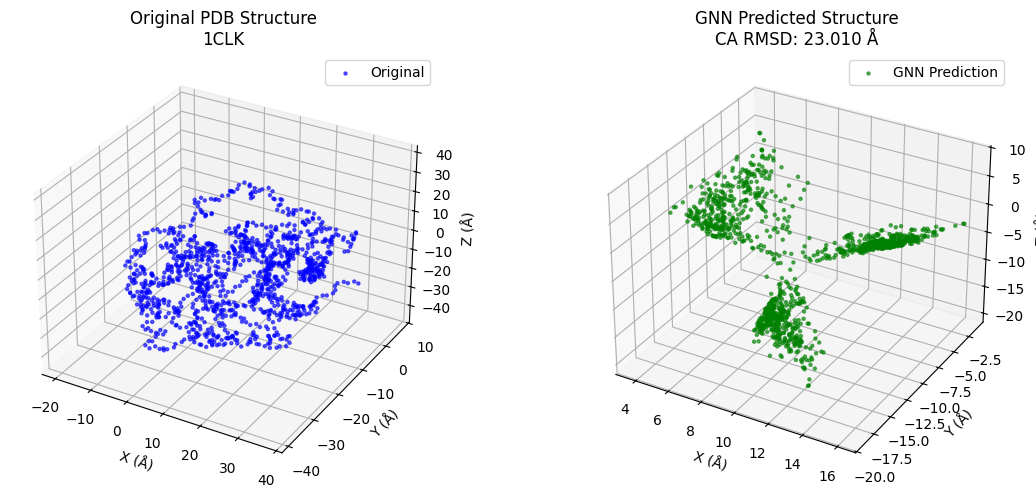


Wrote PDB file:
  1CLK_gnn_predicted.pdb


In [76]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from Bio.PDB import Superimposer, Atom

# Use CA atoms for superposition (original test CA)
test_ca_orig_list = [Atom.Atom('CA', coord, 0.0, 0.0, '', 'CA', i) for i, coord in enumerate(test_ca_orig)]

# Extract CA from GNN prediction
gnn_ca_coords = gnn_pred_trim.reshape(-1, 3)[1::3]  # Every 3rd atom starting at index 1

gnn_ca_atoms = [Atom.Atom('CA', coord, 0.0, 0.0, '', 'CA', i) for i, coord in enumerate(gnn_ca_coords)]

# Superimpose GNN prediction
sup_gnn = Superimposer()
sup_gnn.set_atoms(test_ca_orig_list[:len(gnn_ca_atoms)], gnn_ca_atoms)
rot_gnn, tran_gnn = sup_gnn.rotran
gnn_pred_aligned = np.dot(gnn_pred_trim, rot_gnn) + tran_gnn
gnn_rmsd_ca = sup_gnn.rms

print(f"\n=== CA RMSD after superposition ===")
print(f"GNN CA RMSD: {gnn_rmsd_ca:.3f} Å")

# Recalculate backbone RMSD after alignment
rmsd_gnn_aligned = calc_rmsd(test_backbone_trim, gnn_pred_aligned)

print(f"\n=== Backbone RMSD after CA superposition ===")
print(f"GNN RMSD: {rmsd_gnn_aligned:.3f} Å")

# Visualize side-by-side: Original and GNN Prediction
fig = plt.figure(figsize=(12, 5))

# Original structure
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(test_backbone_trim[:, 0], test_backbone_trim[:, 1], test_backbone_trim[:, 2], c='blue', s=5, alpha=0.6, label='Original')
ax1.set_title(f'Original PDB Structure\n{test_pdb_id}')
ax1.set_xlabel('X (Å)')
ax1.set_ylabel('Y (Å)')
ax1.set_zlabel('Z (Å)')
ax1.legend()

# GNN prediction
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(gnn_pred_aligned[:, 0], gnn_pred_aligned[:, 1], gnn_pred_aligned[:, 2], c='green', s=5, alpha=0.6, label='GNN Prediction')
ax2.set_title(f'GNN Predicted Structure\nCA RMSD: {gnn_rmsd_ca:.3f} Å')
ax2.set_xlabel('X (Å)')
ax2.set_ylabel('Y (Å)')
ax2.set_zlabel('Z (Å)')
ax2.legend()

plt.tight_layout()
plt.show()

# Write out PDB file for inspection
from convert3D import write_pdb
write_pdb(gnn_pred_aligned, f"{test_pdb_id}_gnn_predicted.pdb")
print(f"\nWrote PDB file:")
print(f"  {test_pdb_id}_gnn_predicted.pdb")